In [1]:
#===============================
#STEP 9: VISUALIZATION & RESEARCH QUESTIONS (YOUR RQs)
#===============================
#RQ1 & RQ2: Are orders/sales higher on holidays?

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [3]:
project_root = os.getcwd()
processed_folder = os.path.join(project_root, "data", "processed")
# Read retail Excel data
order_sales_on_holiday_file = os.path.join(processed_folder, "retail_with_holidays.csv")
order_sales_on_holidays = pd.read_csv(order_sales_on_holiday_file)

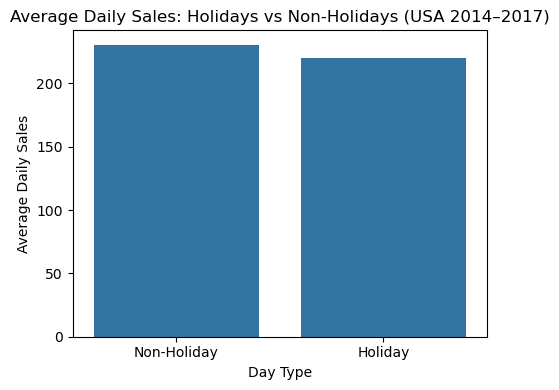

In [4]:
avg_sales = (
    order_sales_on_holidays
    .groupby("Is_Holiday")["Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(5,4))
sns.barplot(
    data=avg_sales,
    x="Is_Holiday",
    y="Sales"
)

plt.xticks([0,1], ["Non-Holiday", "Holiday"])
plt.ylabel("Average Daily Sales")
plt.xlabel("Day Type")
plt.title("Average Daily Sales: Holidays vs Non-Holidays (USA 2014–2017)")
plt.tight_layout()
plt.show()

In [5]:
order_sales_on_holidays

,Order Date,Sales,Quantity,Customer ID,Region,Product ID,Category,Discount,Discount value,Year,Is_Holiday,localName,name
0,2014-06-09,48.860,7,BH-11710,West,FUR-FU-10001487,Furniture,0.0,0.0000,2014,0,No Holiday,No Holiday
1,2014-06-09,7.280,4,BH-11710,West,OFF-AR-10002833,Office Supplies,0.0,0.0000,2014,0,No Holiday,No Holiday
2,2014-06-09,907.152,6,BH-11710,West,TEC-PH-10002275,Technology,0.2,-181.4304,2014,0,No Holiday,No Holiday
3,2014-06-09,18.504,3,BH-11710,West,OFF-BI-10003910,Office Supplies,0.2,-3.7008,2014,0,No Holiday,No Holiday
4,2014-06-09,114.900,5,BH-11710,West,OFF-AP-10002892,Office Supplies,0.0,0.0000,2014,0,No Holiday,No Holiday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,2017-11-17,206.100,5,RA-19885,South,TEC-PH-10004006,Technology,0.0,0.0000,2017,0,No Holiday,No Holiday
9990,2017-02-26,91.960,2,DB-13060,West,FUR-FU-10000747,Furniture,0.0,0.0000,2017,0,No Holiday,No Holiday
9991,2017-02-26,258.576,2,DB-13060,West,TEC-PH-10003645,Technology,0.2,-51.7152,2017,0,No Holiday,No Holiday
9992,2017-02-26,29.600,4,DB-13060,West,OFF-PA-10004041,Office Supplies,0.0,0.0000,2017,0,No Holiday,No Holiday


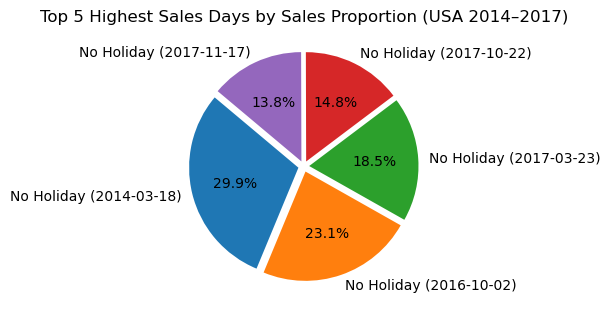

In [6]:
# ==================================================
# RQ2: Top 5 highest sales days (Pie chart)
# ==================================================

# Get top 5 highest sales days
top5_sales = order_sales_on_holidays.nlargest(5, "Sales")[["Order Date", "Sales", "name"]]
top5_sales['Order Date'] = pd.to_datetime(top5_sales['Order Date'])

labels = [
    f"{row['name']} ({row['Order Date'].strftime('%Y-%m-%d')})" 
    if row['name'] != "None" else row['Order Date'].strftime('%Y-%m-%d')
    for _, row in top5_sales.iterrows()
]
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    top5_sales["Sales"], 
    labels=labels,  
    autopct='%1.1f%%',  
    startangle=140, 
    explode=[0.05]*5
)
plt.title("Top 5 Highest Sales Days by Sales Proportion (USA 2014–2017)")
plt.tight_layout()
plt.show()

Top 5 Holidays by Sales:
      Order Date     Sales                         name
8824  2017-01-16  5443.960  Martin Luther King, Jr. Day
7742  2017-05-08  3359.952                   Truman Day
3199  2015-05-08  2799.944                   Truman Day
6280  2016-11-11  2678.940                 Veterans Day
5451  2016-05-30  2275.500                 Memorial Day


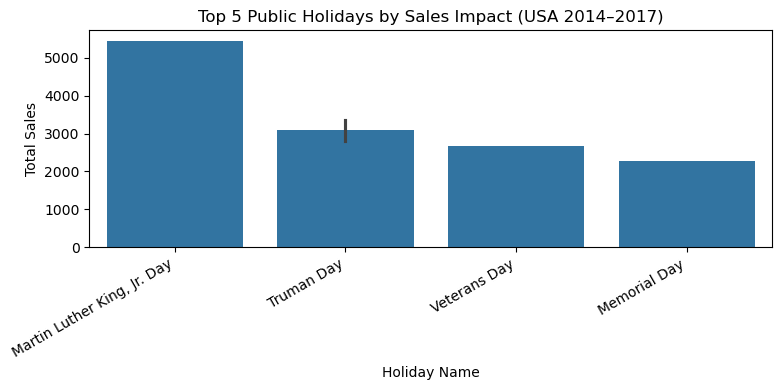

In [7]:
#RQ3: Which holidays have the greatest impact?
top5_holidays = (
    order_sales_on_holidays
    [order_sales_on_holidays["Is_Holiday"] == 1]
    .nlargest(5, "Sales")
    [["Order Date", "Sales", "name"]]
)

print("Top 5 Holidays by Sales:")
print(top5_holidays)

plt.figure(figsize=(8,4))
sns.barplot(
    data=top5_holidays,
    x="name",
    y="Sales"
)

plt.xlabel("Holiday Name")
plt.ylabel("Total Sales")
plt.title("Top 5 Public Holidays by Sales Impact (USA 2014–2017)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

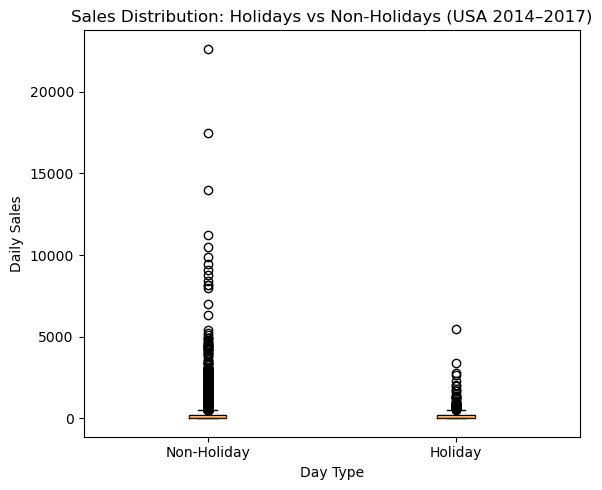

In [8]:
non_holiday_sales = order_sales_on_holidays[
    order_sales_on_holidays["Is_Holiday"] == 0
]["Sales"]

holiday_sales = order_sales_on_holidays[
    order_sales_on_holidays["Is_Holiday"] == 1
]["Sales"]

plt.figure(figsize=(6,5))

plt.boxplot(
    [non_holiday_sales, holiday_sales],
    tick_labels=["Non-Holiday", "Holiday"]
)

plt.ylabel("Daily Sales")
plt.xlabel("Day Type")
plt.title("Sales Distribution: Holidays vs Non-Holidays (USA 2014–2017)")
plt.tight_layout()
plt.show()